# 04: Compact CNN for steel surface defect classification

Install first, from the project folder:
```bat
venv\Scripts\python.exe -m pip install torch==2.14.0 torchvision==0.29.0 numpy pandas matplotlib pillow scikit-learn
```

**Purpose:** compare a learned image representation with the completed HOG + SVM baseline, under exactly the same development folds. This notebook uses greyscale 200 × 200 images and CPU training. It does not open, predict on or evaluate any locked test image.

Run notebooks 02 and 02a successfully first. Start Jupyter in the project root, restart the kernel and run all cells in order. The core model, data preparation, training and evaluation code is visible here, without private modules. The final submission will inline the preparation sections so it does not depend on previously generated CSV files.

**Experimental scope:** one declared architecture and training configuration, five fixed folds, at most 25 epochs per fold, and validation-macro-F1 checkpoint selection. This is a bounded development experiment, not a search for an architecture that outperforms SVM at any cost. No result in this notebook is a final test score.

## 1. Verify the existing experiment before accessing images

The preparation PASS reports, manifest, fold table and their checksums must agree. The latest successful classical run must reference those same split and fold hashes. Only development rows enter the image loader. Reading the saved manifest to establish this permission boundary does not read any test image pixels. Unknown or non-development paths are rejected before file access.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
from importlib.metadata import version
import hashlib
import json
import math
import os
import platform
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

ROOT = Path.cwd().resolve()
METRICS = ROOT / 'outputs' / 'metrics'
REPORTS = ROOT / 'outputs' / 'reports'
CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
CLASS_TO_INDEX = {name: i for i, name in enumerate(CLASSES)}
CHECKS = []
def require(name, passed, detail=''):
    CHECKS.append({'check': name, 'status': 'PASS' if bool(passed) else 'FAIL', 'detail': str(detail)})
    if not bool(passed):
        if 'RUN' in globals():
            pd.DataFrame(CHECKS).to_csv(RUN/'acceptance_checks.csv', index=False)
            (RUN/'status.json').write_text(json.dumps({'status':'FAIL','failed_check':name}), encoding='utf-8')
        raise RuntimeError(f'{name}: {detail}')
def file_sha(path):
    h=hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024*1024), b''): h.update(block)
    return h.hexdigest()
def read_json(path): return json.loads(path.read_text(encoding='utf-8'))
def write_json(path, value):
    temporary=path.with_suffix(path.suffix+'.tmp')
    temporary.write_text(json.dumps(value,indent=2,allow_nan=False), encoding='utf-8')
    temporary.replace(path)

ARTIFACTS = {
    'manifest': METRICS/'data_split_manifest.csv', 'split_lock': METRICS/'split_lock.json',
    'folds': METRICS/'development_cv_folds.csv', 'fold_lock': METRICS/'development_cv_lock.json',
    'split_status': REPORTS/'02_split_status.json', 'fold_status': REPORTS/'02a_validation_status.json',
    'classical_pointer': REPORTS/'03_classical_latest.json'}
require('Required preparation artefacts exist', all(p.is_file() for p in ARTIFACTS.values()))
source_hashes={name:file_sha(path) for name,path in ARTIFACTS.items()}
split_lock=read_json(ARTIFACTS['split_lock'])
fold_lock=read_json(ARTIFACTS['fold_lock'])
split_status=read_json(ARTIFACTS['split_status'])
fold_status=read_json(ARTIFACTS['fold_status'])
require('Preparation passed', split_status['status']==fold_status['status']=='PASS')
require('Split hashes agree', source_hashes['manifest']==split_lock['manifest_sha256']==fold_lock['split_manifest_sha256']
        ==split_status['manifest_sha256']==fold_status['split_manifest_sha256'])
require('Fold hashes agree', source_hashes['folds']==fold_lock['folds_sha256']==fold_status['folds_sha256'])
require('Fixed protocol recognised', split_lock['classes']==CLASSES and split_lock['seed']==fold_lock['seed']==42
        and fold_lock['n_folds']==5 and split_lock['test_size']==0.2)
classical_pointer=read_json(ARTIFACTS['classical_pointer'])
classical_run=(ROOT/classical_pointer['run_directory']).resolve()
require('Classical result path inside outputs', classical_run.is_relative_to(ROOT/'outputs'))
classical_result_path=classical_run/'result.json'
require('Classical result verified', file_sha(classical_result_path)==classical_pointer['result_sha256'])
classical_result=read_json(classical_result_path)
require('Same folds as classical model', classical_result['status']=='PASS' and
        classical_result['source_digests']['manifest']==source_hashes['manifest'] and
        classical_result['source_digests']['folds']==source_hashes['folds'] and
        classical_result['test_evaluation_performed'] is False)
ARTIFACTS['classical_result']=classical_result_path
source_hashes['classical_result']=file_sha(classical_result_path)

manifest=pd.read_csv(ARTIFACTS['manifest'],keep_default_na=False)
folds=pd.read_csv(ARTIFACTS['folds'],keep_default_na=False)
require('Manifest path uniqueness', manifest.path.is_unique and folds.path.is_unique)
development=manifest.loc[manifest.split.eq('development')].sort_values('path').reset_index(drop=True)
require('Development count and classes', len(development)==1439 and set(development.class_name)==set(CLASSES))
require('Folds exactly cover development', set(folds.path)==set(development.path))
folds=folds.set_index('path').loc[development.path].reset_index()
for column in ['path','class_name','sha256','pixel_sha256']:
    require(f'Fold metadata agrees: {column}', folds[column].equals(development[column]))
development['validation_fold']=folds.validation_fold.to_numpy()
require('Exactly five predefined folds', set(development.validation_fold)==set(range(5)))
for column in ['sha256','pixel_sha256']:
    require(f'Unique development content: {column}', development[column].is_unique)
ALLOWED_PATHS=frozenset(development.path)
NON_DEVELOPMENT_PATHS=frozenset(manifest.loc[~manifest.split.eq('development'),'path'])
require('Development permission boundary disjoint', not ALLOWED_PATHS & NON_DEVELOPMENT_PATHS)
FOLD_INDICES=[]
for fold in range(5):
    train=np.flatnonzero(development.validation_fold.to_numpy()!=fold)
    valid=np.flatnonzero(development.validation_fold.to_numpy()==fold)
    require(f'Fold {fold}: disjoint and complete', not set(train)&set(valid) and len(train)+len(valid)==1439)
    require(f'Fold {fold}: all six classes', set(development.iloc[train].class_name)==set(development.iloc[valid].class_name)==set(CLASSES))
    FOLD_INDICES.append((train,valid))
require('Validation coverage exactly once', np.array_equal(np.sort(np.concatenate([v for _,v in FOLD_INDICES])),np.arange(1439)))
# Remove the full manifest so modelling functions cannot accidentally select its test rows.
del manifest, folds
print('PASS: same locked split and five folds as HOG-SVM; no image files opened yet.')

PASS: same locked split and five folds as HOG-SVM; no image files opened yet.


## 2. Predeclare the CPU experiment

| Decision | Choice and methodological rationale |
| --- | --- |
| Architecture | Three Conv2d, BatchNorm, non-inplace ReLU and MaxPool blocks, with 8, 16 and 32 channels. The first convolution has stride 2 to reduce CPU cost while accepting the full 200 × 200 input. Downsampling can discard fine texture, so compactness is a trade-off rather than a claim of optimality. |
| Head | Adaptive average pooling to 1 × 1, dropout 0.25 and six logits. Global pooling reduces dense-layer parameters and sensitivity to location, but can lose useful spatial arrangements. No pretrained weights or external training data. |
| Normalisation | One global greyscale mean and standard deviation estimated from the current fold's training pixels only. The validation subset uses those frozen values. BatchNorm running statistics update only in training mode. |
| Optimiser | AdamW, learning rate 0.001, weight decay 0.0001. Adaptive updates provide a practical initial optimiser; decoupled weight decay supplies modest regularisation. These are declared baseline choices, not empirically proven optima. |
| Batch size | 32, balancing CPU memory and gradient variability. Keep the final incomplete batch so no example is discarded. BatchNorm also uses spatial samples. |
| Dropout | 0.25 before the classifier, a modest regulariser for a small dataset. Disabled during diagnostics and validation. |
| Training bound | At most 25 epochs per fold. Stop after five consecutive epochs without a strictly higher validation macro F1. Earliest epoch wins exact ties. Save every new best checkpoint. Validation loss is recorded but never used to choose a checkpoint, stop training or change learning rate. |
| Search budget | One configuration and all five existing folds. No reduced-fold shortcut, scheduler, augmentation search or performance-driven rerun. Omit augmentation for this controlled baseline rather than assume that rotations/flips preserve industrial defect meaning. |
| Final development refit | After CV, train a fresh model on all development images for the ceiling of the median selected fold epoch. This rule is fixed now; do not select the final refit using a hold-out score. Fold checkpoints are the validation evidence. |

Training and validation loss and macro F1 are measured at the **end of each epoch in evaluation mode**, with the same weights and no dropout. Online optimisation loss is recorded separately. This adds some CPU cost but makes learning curves more interpretable.

Seeds cover Python, NumPy, PyTorch and shuffled loaders. Use four CPU threads, zero data-loader workers and deterministic algorithms. This improves repeatability on the recorded software/hardware stack; it does not promise bitwise equality across operating systems, PyTorch versions or CPU implementations. Each fold starts from new weights and a new optimiser.

In [2]:
DEVICE=torch.device('cpu')
CONFIG={'seed':42,'channels':[8,16,32],'input_shape':[1,200,200],
        'first_conv_stride':2,'dropout':0.25,'learning_rate':0.001,'weight_decay':0.0001,
        'batch_size':32,'max_epochs':25,'patience':5,'threads':min(4,os.cpu_count() or 1),
        'num_workers':0,'augmentation':'none','selection':'strictly highest validation macro F1; earliest tie',
        'refit_epoch_rule':'ceiling of median best fold epoch'}
torch.set_num_threads(CONFIG['threads'])
torch.use_deterministic_algorithms(True)
def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
seed_everything(CONFIG['seed'])
environment={'python':platform.python_version(),'executable':sys.executable,'platform':platform.platform(),
    'processor':platform.processor(),'logical_cpus':os.cpu_count(),'torch_threads':torch.get_num_threads(),
    'device':str(DEVICE),'cuda_available':torch.cuda.is_available(),
    'deterministic_algorithms':torch.are_deterministic_algorithms_enabled(),
    'packages':{p:version(p) for p in ['torch','torchvision','numpy','pandas','matplotlib','pillow','scikit-learn']}}
try: environment['packages']['captum']=version('captum')
except Exception: environment['packages']['captum']='not installed; optional for later explanations'
run_id=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
RUN=ROOT/'outputs'/'experiments'/('04_cnn_'+run_id)
RUN.mkdir(parents=True,exist_ok=False)
(RUN/'checkpoints').mkdir()
write_json(RUN/'status.json',{'status':'IN_PROGRESS','stage':'safeguards'})
write_json(RUN/'protocol.json',{'run_id':run_id,'config':CONFIG,'classes':CLASSES,
    'class_to_index':CLASS_TO_INDEX,'source_hashes':source_hashes,'environment':environment,
    'interpretation':'development checkpoint selection, not final test or nested validation'})
print('Run:',RUN)
print(json.dumps(environment,indent=2))

Run: C:\Scripts\industrial-defect-intelligence\outputs\experiments\04_cnn_20260925T222923_890724Z
{
  "python": "3.14.0",
  "executable": "C:\\Scripts\\industrial-defect-intelligence\\venv\\Scripts\\python.exe",
  "platform": "Windows-11-10.0.26200-SP0",
  "processor": "Intel64 Family 6 Model 186 Stepping 3, GenuineIntel",
  "logical_cpus": 12,
  "torch_threads": 4,
  "device": "cpu",
  "cuda_available": false,
  "deterministic_algorithms": true,
  "packages": {
    "torch": "2.14.0",
    "torchvision": "0.29.0",
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
    "pillow": "12.3.0",
    "scikit-learn": "1.9.1",
    "captum": "0.9.0"
  }
}


## 3. Development-only image access and fold normalisation

Cache only the 1,439 allowed development images as uint8 arrays, approximately 55 MiB. Each image is hash-checked and decoded at its original 200 × 200 size. Converting batches to float and normalising happens in the dataset object, without editing raw images. The loader records successful image accesses; a negative test verifies that a non-development path is refused before opening a file.

These guards and logs are evidence about this notebook's execution, not a security guarantee about unrelated programs or earlier manual inspection. Earlier EDA covered the full collection; retain that limitation. No new test image inspection occurs here.

In [3]:
image_access=[]
def load_allowed_image(relative_path):
    if relative_path not in ALLOWED_PATHS:
        raise PermissionError('Only the development allow-list may be opened in notebook 04.')
    path=(ROOT/relative_path).resolve()
    if not path.is_relative_to((ROOT/'data'/'NEU-CLS').resolve()):
        raise PermissionError('Image path escaped the dataset directory.')
    with Image.open(path) as image:
        if image.size!=(200,200): raise ValueError(f'Unexpected size: {relative_path}')
        array=np.array(image.convert('L'),dtype=np.uint8)
    image_access.append(relative_path)
    return array

before_access=len(image_access)
try:
    load_allowed_image(sorted(NON_DEVELOPMENT_PATHS)[0])
except PermissionError:
    denied_correctly=True
else:
    denied_correctly=False
require('Non-development loader request blocked before access', denied_correctly and len(image_access)==before_access)
start=perf_counter()
images=np.empty((len(development),200,200),dtype=np.uint8)
for index,row in enumerate(development.itertuples()):
    require(f'Image hash {index}',file_sha(ROOT/row.path)==row.sha256,row.path)
    images[index]=load_allowed_image(row.path)
load_seconds=perf_counter()-start
labels=np.array([CLASS_TO_INDEX[x] for x in development.class_name],dtype=np.int64)
require('All and only development images loaded', set(image_access)==set(ALLOWED_PATHS) and len(image_access)==1439)

def training_normalisation(indices):
    # Computed over training pixels only, in float64 to avoid integer overflow.
    pixels=images[indices]
    mean=float(pixels.mean(dtype=np.float64)/255.0)
    std=float(pixels.std(dtype=np.float64)/255.0)
    if not math.isfinite(mean) or not math.isfinite(std) or std<=1e-8:
        raise ValueError('Invalid training normalisation.')
    return mean,std

class DevelopmentDataset(Dataset):
    def __init__(self,indices,mean,std):
        self.indices=np.array(indices,dtype=np.int64)
        if not len(self.indices) or len(set(self.indices))!=len(self.indices) or self.indices.min()<0 or self.indices.max()>=len(development):
            raise ValueError('Dataset indices must be unique development rows.')
        self.mean,self.std=float(mean),float(std)
    def __len__(self): return len(self.indices)
    def __getitem__(self,index):
        position=int(self.indices[index])
        x=torch.from_numpy(images[position]).unsqueeze(0).float().div(255.0)
        x=(x-self.mean)/self.std
        return x,int(labels[position]),position

def make_loader(indices,mean,std,shuffle=False,seed=42):
    generator=torch.Generator().manual_seed(seed)
    return DataLoader(DevelopmentDataset(indices,mean,std),batch_size=CONFIG['batch_size'],
        shuffle=shuffle,drop_last=False,num_workers=0,generator=generator)

normalisation=[]
for fold,(train,valid) in enumerate(FOLD_INDICES):
    mean,std=training_normalisation(train)
    normalisation.append({'fold':fold,'mean':mean,'std':std,'training_images':len(train),
        'validation_images':len(valid),'fitted_on':'training subset only'})
pd.DataFrame(normalisation).to_csv(RUN/'fold_normalisation.csv',index=False)
display(pd.DataFrame(normalisation))
print(f'Cached {len(images)} development images: {images.nbytes/1024**2:.1f} MiB, {load_seconds:.1f}s including integrity checks.')

,fold,mean,std,training_images,validation_images,fitted_on
0,0,0.504116,0.211441,1151,288,training subset only
1,1,0.502400,0.213103,1151,288,training subset only
2,2,0.502099,0.211518,1151,288,training subset only
3,3,0.505010,0.213203,1151,288,training subset only
4,4,0.501666,0.213830,1152,287,training subset only


Cached 1439 development images: 54.9 MiB, 4.8s including integrity checks.


## 4. Architecture, reproducibility and CPU smoke checks

The feature-map sizes are 100 × 100 after the first strided convolution, then 50 × 50, 25 × 25 and 12 × 12 after the three pooling stages. The final convolution (`conv3`) exposes 25 × 25 feature maps for later Captum LayerGradCam. Non-inplace activations retain a straightforward autograd path. The classifier returns logits; CrossEntropyLoss applies the required normalisation internally.

Before any real fold training, a synthetic batch checks output shape, finite gradients, deterministic repeatability and approximate batch runtime. It is discarded, and each real fold is reseeded. The smoke check neither uses validation data nor chooses hyperparameters on performance. A runtime projection is approximate and excludes diagnostic passes and competing CPU activity.

In [4]:
class CompactCNN(nn.Module):
    def __init__(self,dropout=0.25):
        super().__init__()
        self.conv1=nn.Conv2d(1,8,3,stride=2,padding=1,bias=False)
        self.bn1=nn.BatchNorm2d(8)
        self.conv2=nn.Conv2d(8,16,3,padding=1,bias=False)
        self.bn2=nn.BatchNorm2d(16)
        self.conv3=nn.Conv2d(16,32,3,padding=1,bias=False)
        self.bn3=nn.BatchNorm2d(32)
        self.relu=nn.ReLU(inplace=False)
        self.pool=nn.MaxPool2d(2)
        self.average=nn.AdaptiveAvgPool2d((1,1))
        self.dropout=nn.Dropout(dropout)
        self.classifier=nn.Linear(32,len(CLASSES))
    def forward(self,x):
        x=self.pool(self.relu(self.bn1(self.conv1(x))))
        x=self.pool(self.relu(self.bn2(self.conv2(x))))
        x=self.pool(self.relu(self.bn3(self.conv3(x))))
        x=self.average(x).flatten(1)
        return self.classifier(self.dropout(x))

def new_model(seed):
    seed_everything(seed)
    return CompactCNN(CONFIG['dropout']).to(DEVICE)

def synthetic_step(seed):
    model=new_model(seed)
    x=torch.linspace(-1,1,4*200*200).reshape(4,1,200,200)
    y=torch.tensor([0,1,2,3])
    optimizer=torch.optim.AdamW(model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
    logits=model(x)
    loss=nn.functional.cross_entropy(logits,y)
    loss.backward()
    finite=all(p.grad is None or torch.isfinite(p.grad).all().item() for p in model.parameters())
    optimizer.step()
    return model,logits.detach(),finite
smoke_a,logits_a,finite_a=synthetic_step(1234)
smoke_b,logits_b,finite_b=synthetic_step(1234)
require('Six finite logits and finite gradients',logits_a.shape==(4,6) and torch.isfinite(logits_a).all().item() and finite_a and finite_b)
require('Same-seed synthetic update reproducible',torch.equal(logits_a,logits_b) and
        all(torch.equal(a,b) for a,b in zip(smoke_a.state_dict().values(),smoke_b.state_dict().values())))
PARAMETERS=sum(p.numel() for p in smoke_a.parameters() if p.requires_grad)
# Optional compatibility check if Captum is installed. No claim of explanation quality.
captum_check='not installed; hook/gradient compatibility retained by architecture'
try:
    from captum.attr import LayerGradCam
except ImportError:
    pass
else:
    smoke_a.eval()
    attribution=LayerGradCam(smoke_a,smoke_a.conv3).attribute(torch.zeros(1,1,200,200,requires_grad=True),target=0,relu_attributions=True)
    require('Captum synthetic LayerGradCam compatibility',attribution.shape==(1,1,25,25) and torch.isfinite(attribution).all().item())
    captum_check='PASS: synthetic attribution shape 1x1x25x25, finite'
benchmark=new_model(1235)
optimizer=torch.optim.AdamW(benchmark.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
dummy_x=torch.zeros(CONFIG['batch_size'],1,200,200)
dummy_y=torch.arange(CONFIG['batch_size'])%6
times=[]
for repeat in range(4):
    start=perf_counter()
    optimizer.zero_grad(set_to_none=True)
    nn.functional.cross_entropy(benchmark(dummy_x),dummy_y).backward()
    optimizer.step()
    if repeat: times.append(perf_counter()-start)
batch_seconds=float(np.median(times))
write_json(RUN/'preflight.json',{'status':'PASS','parameters':PARAMETERS,'synthetic_train_batch_seconds':batch_seconds,
    'captum_check':captum_check,'no_real_images_used_for_smoke_training':True})
print(benchmark)
print(f'Trainable parameters: {PARAMETERS:,}; synthetic batch median: {batch_seconds:.3f}s')
print(f'Approximate training-pass time per fold epoch: {math.ceil(1152/CONFIG["batch_size"])*batch_seconds:.1f}s, plus diagnostics.')
del smoke_a,smoke_b,benchmark,optimizer,dummy_x,dummy_y

CompactCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (average): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout(p=0.25, inplace=False)
  (classifier): Linear(in_features=32, out_features=6, bias=True)
)
Trainable parameters: 6,142; synthetic batch median: 0.086s
Approximate training-pass time per fold epoch: 3.1s, plus diagnostics.


## 5. Training and evaluation functions

Each evaluation returns row indices, labels and predictions so coverage is checked explicitly. Training and validation are separate loaders over disjoint predefined indices. Macro metrics include all six classes even if a class is never predicted. BatchNorm buffers must remain unchanged during evaluation. Checkpoint selection uses validation macro F1 only; ties do not reset patience.

For each fold, save the best state dictionary, class map, normalisation, seed and split/fold hashes. Checkpoints are for inference and explanation, not interrupted-training resumption. A fresh run gets a new output directory; failed or partial runs are never marked as completed. Do not select a preferred random-seed run after looking at its scores.

In [5]:
LOSS=nn.CrossEntropyLoss()
def classification_metrics(truth,pred):
    precision,recall,f1,_=precision_recall_fscore_support(truth,pred,labels=np.arange(6),average='macro',zero_division=0)
    return {'accuracy':float(accuracy_score(truth,pred)),'precision_macro':float(precision),
            'recall_macro':float(recall),'f1_macro':float(f1)}

def train_epoch(model,loader,optimizer):
    model.train()
    total_loss,total=0.0,0
    for x,y,_ in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits=model(x)
        loss=LOSS(logits,y)
        if not torch.isfinite(loss): raise RuntimeError('Non-finite training loss.')
        loss.backward()
        optimizer.step()
        total_loss+=float(loss.detach())*len(y)
        total+=len(y)
    if total!=len(loader.dataset): raise RuntimeError('Training coverage mismatch.')
    return total_loss/total

@torch.inference_mode()
def evaluate(model,loader):
    model.eval()
    before={name:buffer.clone() for name,buffer in model.named_buffers()}
    truth,pred,positions=[],[],[]
    total_loss,total=0.0,0
    for x,y,index in loader:
        logits=model(x.to(DEVICE))
        loss=LOSS(logits,y.to(DEVICE))
        if not torch.isfinite(logits).all() or not torch.isfinite(loss):
            raise RuntimeError('Non-finite evaluation output.')
        total_loss+=float(loss)*len(y); total+=len(y)
        truth.extend(y.numpy().tolist()); pred.extend(logits.argmax(1).cpu().numpy().tolist())
        positions.extend(index.numpy().tolist())
    if total!=len(loader.dataset) or sorted(positions)!=sorted(loader.dataset.indices.tolist()):
        raise RuntimeError('Evaluation coverage mismatch.')
    if not all(torch.equal(before[name],buffer) for name,buffer in model.named_buffers()):
        raise RuntimeError('BatchNorm buffers changed during evaluation.')
    return {'loss':total_loss/total,**classification_metrics(truth,pred)},np.array(positions),np.array(pred)

def checkpoint_payload(model,fold,epoch,score,mean,std,seed):
    return {'state_dict':{k:v.detach().cpu().clone() for k,v in model.state_dict().items()},
        'fold':fold,'epoch':epoch,'validation_macro_f1':score,'mean':float(mean),'std':float(std),
        'classes':CLASSES,'class_to_index':CLASS_TO_INDEX,'config':CONFIG,'seed':seed,
        'manifest_sha256':source_hashes['manifest'],'folds_sha256':source_hashes['folds']}

def save_checkpoint(path,payload):
    temporary=path.with_suffix('.pt.tmp')
    torch.save(payload,temporary)
    temporary.replace(path)

fold_results=[]
all_histories=[]
oof_predictions=np.full(len(development),-1,dtype=np.int64)
oof_coverage=np.zeros(len(development),dtype=np.int64)
evaluation_registry=[]

def run_fold(fold):
    train,valid=FOLD_INDICES[fold]
    seed=CONFIG['seed']+fold
    mean,std=normalisation[fold]['mean'],normalisation[fold]['std']
    model=new_model(seed)
    optimizer=torch.optim.AdamW(model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
    train_loader=make_loader(train,mean,std,shuffle=True,seed=seed)
    train_diagnostic_loader=make_loader(train,mean,std)
    valid_loader=make_loader(valid,mean,std)
    best_score,best_epoch,stale=-math.inf,0,0
    history=[]
    checkpoint=RUN/'checkpoints'/f'fold_{fold}_best.pt'
    fold_start=perf_counter()
    for epoch in range(1,CONFIG['max_epochs']+1):
        start=perf_counter()
        online_loss=train_epoch(model,train_loader,optimizer)
        fit_seconds=perf_counter()-start
        start=perf_counter()
        train_metrics,_,_=evaluate(model,train_diagnostic_loader)
        train_diagnostic_seconds=perf_counter()-start
        start=perf_counter()
        valid_metrics,_,_=evaluate(model,valid_loader)
        validation_seconds=perf_counter()-start
        improved=valid_metrics['f1_macro']>best_score
        if improved:
            best_score,best_epoch,stale=valid_metrics['f1_macro'],epoch,0
            save_checkpoint(checkpoint,checkpoint_payload(model,fold,epoch,best_score,mean,std,seed))
        else:
            stale+=1
        history.append({'fold':fold,'epoch':epoch,'online_train_loss':online_loss,
            'train_loss':train_metrics['loss'],'train_macro_f1':train_metrics['f1_macro'],
            'validation_loss':valid_metrics['loss'],'validation_macro_f1':valid_metrics['f1_macro'],
            'fit_seconds':fit_seconds,'train_diagnostic_seconds':train_diagnostic_seconds,
            'validation_seconds':validation_seconds,'selected_checkpoint':improved,'patience_used':stale})
        pd.DataFrame(history).to_csv(RUN/f'fold_{fold}_history.csv',index=False)
        write_json(RUN/'progress.json',{'stage':'cross_validation','fold':fold,'epoch':epoch,
            'best_epoch':best_epoch,'best_validation_macro_f1':best_score,'patience_used':stale})
        print(f'Fold {fold+1}/5 | epoch {epoch:02d}/{CONFIG["max_epochs"]} | train F1 {train_metrics["f1_macro"]:.4f} | validation F1 {valid_metrics["f1_macro"]:.4f} | best {best_epoch} | patience {stale}/{CONFIG["patience"]}',flush=True)
        if stale>=CONFIG['patience']: break
    fold_wall_seconds=perf_counter()-fold_start
    payload=torch.load(checkpoint,map_location='cpu',weights_only=True)
    model.load_state_dict(payload['state_dict'])
    start=perf_counter()
    selected_metrics,positions,predictions=evaluate(model,valid_loader)
    selected_prediction_seconds=perf_counter()-start
    require(f'Fold {fold}: best checkpoint reproduced',abs(selected_metrics['f1_macro']-best_score)<1e-12)
    require(f'Fold {fold}: no repeated OOF predictions',np.all(oof_coverage[positions]==0))
    require(f'Fold {fold}: checkpoint epoch selection',best_epoch==int(pd.DataFrame(history).loc[lambda t:t.validation_macro_f1.eq(t.validation_macro_f1.max()),'epoch'].iloc[0]))
    oof_predictions[positions]=predictions
    oof_coverage[positions]+=1
    evaluation_registry.extend({'fold':fold,'path':str(development.iloc[i].path),'role':'selected_checkpoint_validation'} for i in positions)
    row={'fold':fold,'seed':seed,'train_images':len(train),'validation_images':len(valid),
        'best_epoch':best_epoch,'epochs_run':len(history),'stop_reason':'patience' if stale>=CONFIG['patience'] else 'epoch_limit',
        **selected_metrics,'fold_wall_seconds':fold_wall_seconds,
        'optimisation_seconds':sum(r['fit_seconds'] for r in history),
        'selected_validation_seconds':selected_prediction_seconds,
        'checkpoint_bytes':checkpoint.stat().st_size,'checkpoint_sha256':file_sha(checkpoint)}
    fold_results.append(row)
    all_histories.extend(history)
    pd.DataFrame(fold_results).to_csv(RUN/'fold_metrics.csv',index=False)
    pd.DataFrame(all_histories).to_csv(RUN/'all_fold_histories.csv',index=False)
    print(f'Fold {fold+1} complete: selected epoch {best_epoch}, macro F1 {best_score:.4f}',flush=True)

## 6. Run all five predefined folds

Progress is printed once per epoch and written to `progress.json`. Histories and new best checkpoints are saved during training. Let each cell finish before running it again. No partial-fold result constitutes completed five-fold validation.

In [6]:
run_fold(0)

Fold 1/5 | epoch 01/25 | train F1 0.2976 | validation F1 0.3430 | best 1 | patience 0/5
Fold 1/5 | epoch 02/25 | train F1 0.7733 | validation F1 0.8051 | best 2 | patience 0/5
Fold 1/5 | epoch 03/25 | train F1 0.8153 | validation F1 0.8459 | best 3 | patience 0/5
Fold 1/5 | epoch 04/25 | train F1 0.8304 | validation F1 0.8788 | best 4 | patience 0/5
Fold 1/5 | epoch 05/25 | train F1 0.8510 | validation F1 0.8835 | best 5 | patience 0/5
Fold 1/5 | epoch 06/25 | train F1 0.8661 | validation F1 0.8896 | best 6 | patience 0/5
Fold 1/5 | epoch 07/25 | train F1 0.8801 | validation F1 0.8862 | best 6 | patience 1/5
Fold 1/5 | epoch 08/25 | train F1 0.8936 | validation F1 0.9309 | best 8 | patience 0/5
Fold 1/5 | epoch 09/25 | train F1 0.9011 | validation F1 0.9409 | best 9 | patience 0/5
Fold 1/5 | epoch 10/25 | train F1 0.9030 | validation F1 0.9230 | best 9 | patience 1/5
Fold 1/5 | epoch 11/25 | train F1 0.8091 | validation F1 0.8546 | best 9 | patience 2/5
Fold 1/5 | epoch 12/25 | train F

In [7]:
run_fold(1)

Fold 2/5 | epoch 01/25 | train F1 0.5695 | validation F1 0.5419 | best 1 | patience 0/5
Fold 2/5 | epoch 02/25 | train F1 0.7778 | validation F1 0.7562 | best 2 | patience 0/5
Fold 2/5 | epoch 03/25 | train F1 0.8451 | validation F1 0.8232 | best 3 | patience 0/5
Fold 2/5 | epoch 04/25 | train F1 0.8800 | validation F1 0.8750 | best 4 | patience 0/5
Fold 2/5 | epoch 05/25 | train F1 0.8860 | validation F1 0.8823 | best 5 | patience 0/5
Fold 2/5 | epoch 06/25 | train F1 0.8777 | validation F1 0.8549 | best 5 | patience 1/5
Fold 2/5 | epoch 07/25 | train F1 0.8858 | validation F1 0.8573 | best 5 | patience 2/5
Fold 2/5 | epoch 08/25 | train F1 0.9111 | validation F1 0.8797 | best 5 | patience 3/5
Fold 2/5 | epoch 09/25 | train F1 0.9084 | validation F1 0.8666 | best 5 | patience 4/5
Fold 2/5 | epoch 10/25 | train F1 0.9255 | validation F1 0.9068 | best 10 | patience 0/5
Fold 2/5 | epoch 11/25 | train F1 0.9310 | validation F1 0.9137 | best 11 | patience 0/5
Fold 2/5 | epoch 12/25 | train

In [8]:
run_fold(2)

Fold 3/5 | epoch 01/25 | train F1 0.3049 | validation F1 0.3005 | best 1 | patience 0/5
Fold 3/5 | epoch 02/25 | train F1 0.7875 | validation F1 0.7646 | best 2 | patience 0/5
Fold 3/5 | epoch 03/25 | train F1 0.8635 | validation F1 0.8539 | best 3 | patience 0/5
Fold 3/5 | epoch 04/25 | train F1 0.7855 | validation F1 0.7230 | best 3 | patience 1/5
Fold 3/5 | epoch 05/25 | train F1 0.8338 | validation F1 0.7881 | best 3 | patience 2/5
Fold 3/5 | epoch 06/25 | train F1 0.8635 | validation F1 0.8398 | best 3 | patience 3/5
Fold 3/5 | epoch 07/25 | train F1 0.8750 | validation F1 0.8499 | best 3 | patience 4/5
Fold 3/5 | epoch 08/25 | train F1 0.8983 | validation F1 0.8931 | best 8 | patience 0/5
Fold 3/5 | epoch 09/25 | train F1 0.8075 | validation F1 0.8083 | best 8 | patience 1/5
Fold 3/5 | epoch 10/25 | train F1 0.8523 | validation F1 0.8424 | best 8 | patience 2/5
Fold 3/5 | epoch 11/25 | train F1 0.9036 | validation F1 0.8822 | best 8 | patience 3/5
Fold 3/5 | epoch 12/25 | train F

In [9]:
run_fold(3)

Fold 4/5 | epoch 01/25 | train F1 0.3078 | validation F1 0.3057 | best 1 | patience 0/5
Fold 4/5 | epoch 02/25 | train F1 0.7879 | validation F1 0.7996 | best 2 | patience 0/5
Fold 4/5 | epoch 03/25 | train F1 0.7968 | validation F1 0.7923 | best 2 | patience 1/5
Fold 4/5 | epoch 04/25 | train F1 0.8188 | validation F1 0.7940 | best 2 | patience 2/5
Fold 4/5 | epoch 05/25 | train F1 0.8496 | validation F1 0.8317 | best 5 | patience 0/5
Fold 4/5 | epoch 06/25 | train F1 0.8730 | validation F1 0.8419 | best 6 | patience 0/5
Fold 4/5 | epoch 07/25 | train F1 0.9018 | validation F1 0.8665 | best 7 | patience 0/5
Fold 4/5 | epoch 08/25 | train F1 0.8797 | validation F1 0.8777 | best 8 | patience 0/5
Fold 4/5 | epoch 09/25 | train F1 0.7498 | validation F1 0.7485 | best 8 | patience 1/5
Fold 4/5 | epoch 10/25 | train F1 0.8896 | validation F1 0.9024 | best 10 | patience 0/5
Fold 4/5 | epoch 11/25 | train F1 0.9092 | validation F1 0.8999 | best 10 | patience 1/5
Fold 4/5 | epoch 12/25 | train

In [10]:
run_fold(4)

Fold 5/5 | epoch 01/25 | train F1 0.6271 | validation F1 0.6346 | best 1 | patience 0/5
Fold 5/5 | epoch 02/25 | train F1 0.7685 | validation F1 0.7559 | best 2 | patience 0/5
Fold 5/5 | epoch 03/25 | train F1 0.8246 | validation F1 0.8372 | best 3 | patience 0/5
Fold 5/5 | epoch 04/25 | train F1 0.8193 | validation F1 0.8283 | best 3 | patience 1/5
Fold 5/5 | epoch 05/25 | train F1 0.8697 | validation F1 0.8777 | best 5 | patience 0/5
Fold 5/5 | epoch 06/25 | train F1 0.8531 | validation F1 0.8525 | best 5 | patience 1/5
Fold 5/5 | epoch 07/25 | train F1 0.7972 | validation F1 0.8056 | best 5 | patience 2/5
Fold 5/5 | epoch 08/25 | train F1 0.9088 | validation F1 0.8955 | best 8 | patience 0/5
Fold 5/5 | epoch 09/25 | train F1 0.9053 | validation F1 0.8988 | best 9 | patience 0/5
Fold 5/5 | epoch 10/25 | train F1 0.8538 | validation F1 0.8416 | best 9 | patience 1/5
Fold 5/5 | epoch 11/25 | train F1 0.9025 | validation F1 0.8988 | best 11 | patience 0/5
Fold 5/5 | epoch 12/25 | train 

## 7. Fold summary and development diagnostics

Report mean and **sample standard deviation (ddof=1)** across five folds. Fold SD describes variation between these splits, not a confidence interval: training sets overlap, and only one seed is used per fold. Fold SD reflects both partition and initialisation variation; this experiment does not isolate those sources. Selected validation epochs were chosen using these same validation data. Their scores and pooled out-of-fold predictions therefore carry selection optimism; this is not nested CV or independent final evaluation.

The comparison with HOG-SVM is paired by data partition, but the selection budgets differ: six SVM configurations versus one CNN configuration with epoch selection. Do not interpret a score difference as an isolated causal effect of representation learning. Differences in regularisation, optimisation and capacity also matter.

,fold,best_epoch,epochs_run,stop_reason,accuracy,precision_macro,recall_macro,f1_macro
0,0,20,25,patience,0.965278,0.965586,0.965278,0.965152
1,1,15,20,patience,0.927083,0.935109,0.927083,0.927876
2,2,8,13,patience,0.892361,0.899027,0.892361,0.893120
3,3,23,25,epoch_limit,0.954861,0.956500,0.954861,0.954774
4,4,23,25,epoch_limit,0.947735,0.950251,0.947917,0.947815


,mean,fold_sd
accuracy,0.937464,0.028826
precision_macro,0.941295,0.026107
recall_macro,0.937500,0.028842
f1_macro,0.937747,0.028422


,precision,recall,f1-score,support
crazing,0.950413,0.958333,0.954357,240.000000
inclusion,0.840741,0.945833,0.890196,240.000000
patches,0.953782,0.949791,0.951782,239.000000
pitted_surface,0.933921,0.883333,0.907923,240.000000
rolled_in_scale,1.000000,1.000000,1.000000,240.000000
scratches,0.959459,0.887500,0.922078,240.000000
accuracy,0.937457,0.937457,0.937457,0.937457
macro avg,0.939719,0.937465,0.937723,1439.000000
weighted avg,0.939710,0.937457,0.937713,1439.000000


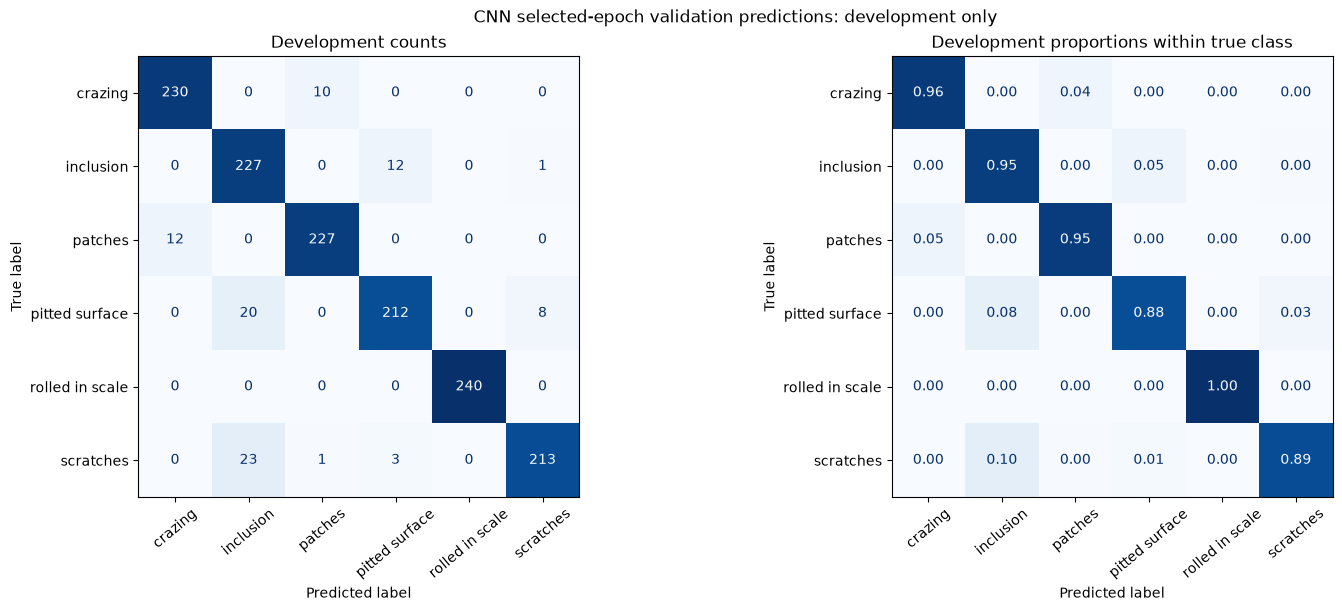

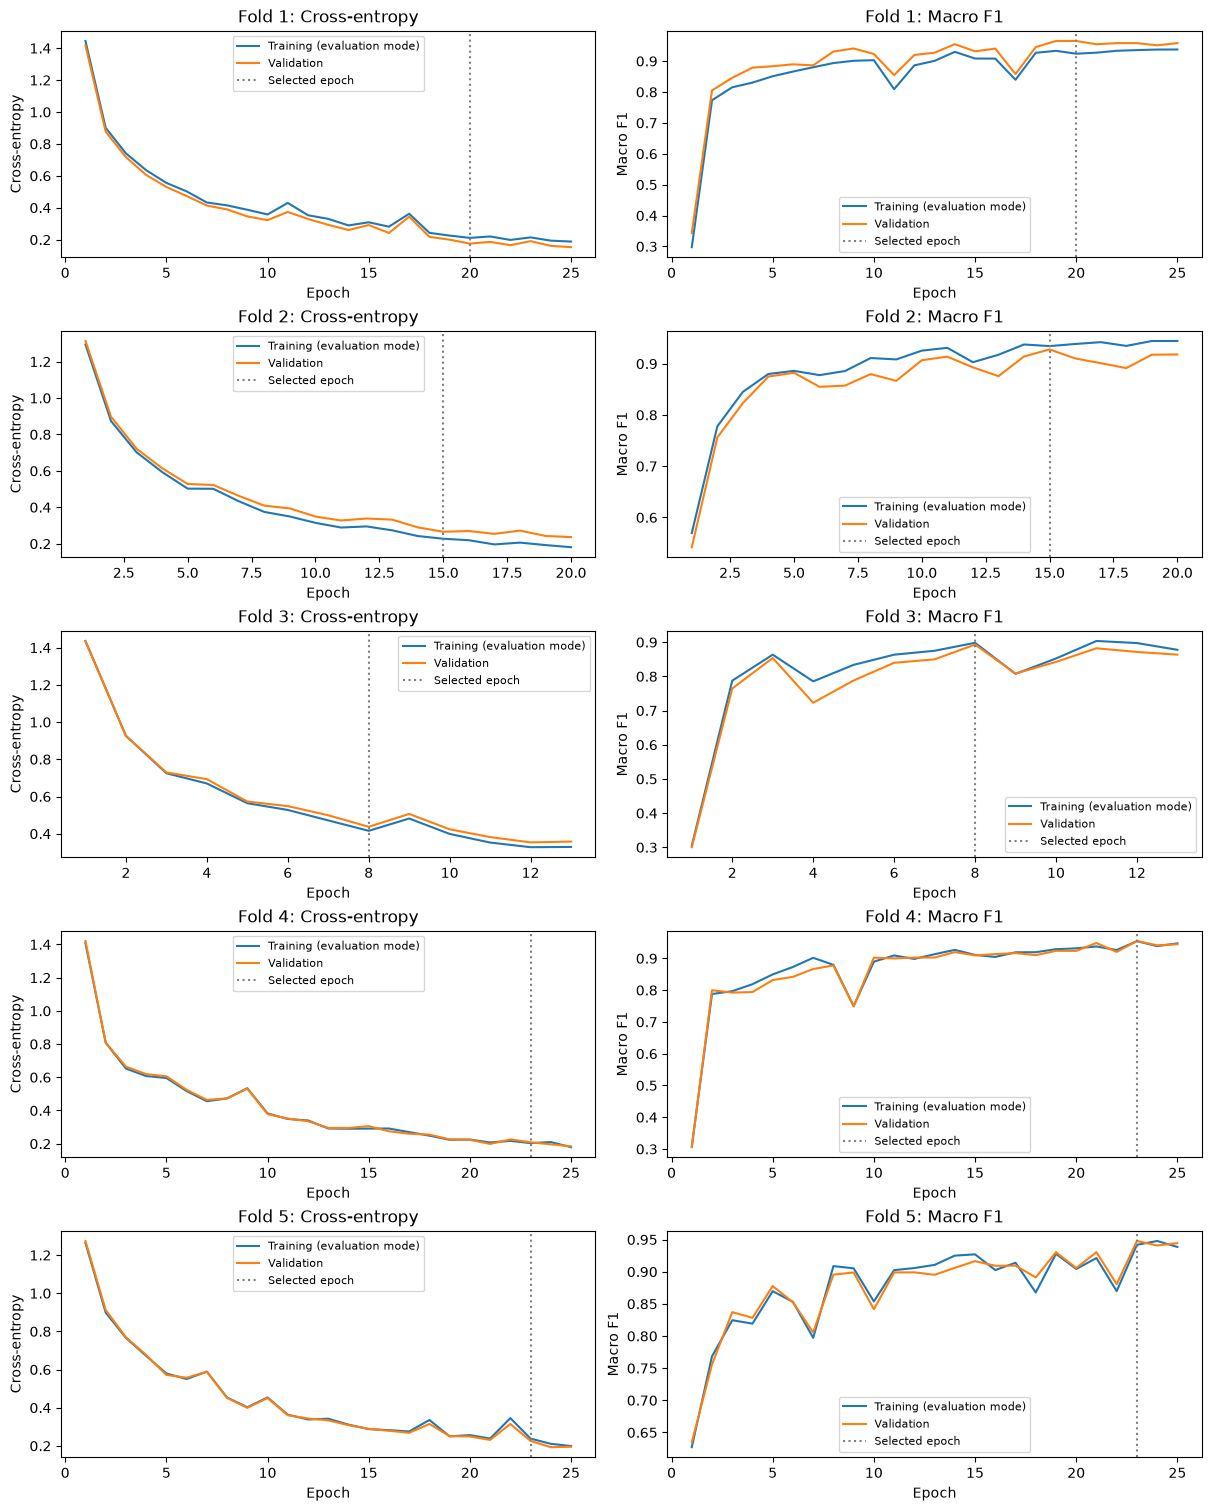

,true_class,predicted_class,count
6,scratches,inclusion,23
4,pitted_surface,inclusion,20
3,patches,crazing,12
1,inclusion,pitted_surface,12
0,crazing,patches,10
5,pitted_surface,scratches,8
8,scratches,pitted_surface,3
2,inclusion,scratches,1


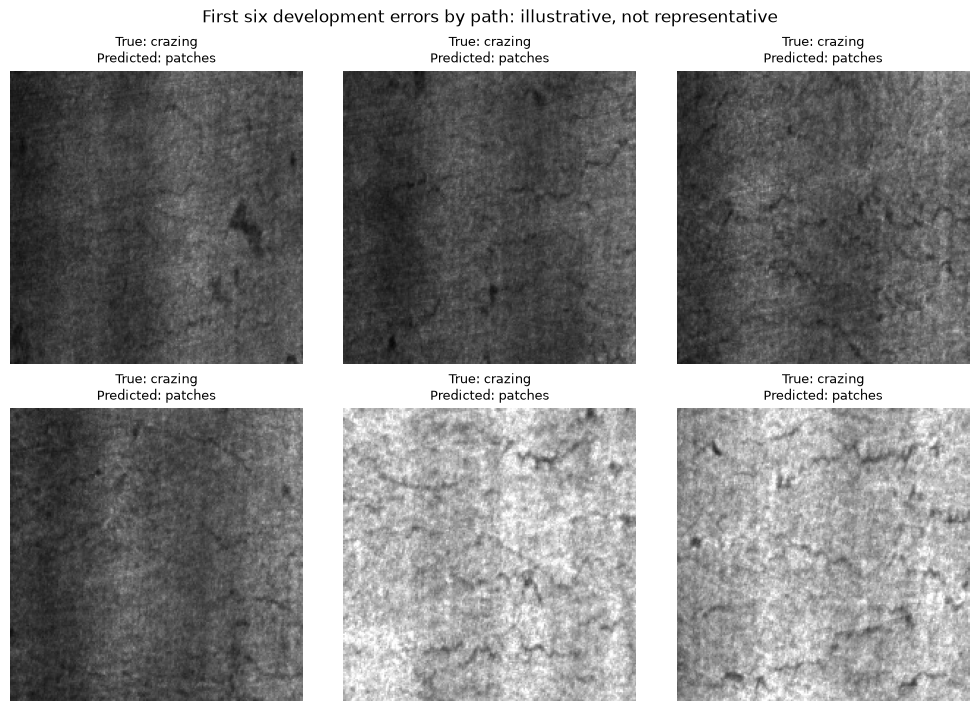

,fold,f1_macro_cnn,f1_macro_svm,cnn_minus_svm
0,0,0.965152,0.908763,0.056390
1,1,0.927876,0.883789,0.044087
2,2,0.893120,0.882502,0.010618
3,3,0.954774,0.883882,0.070892
4,4,0.947815,0.876631,0.071184


In [11]:
require('All five folds completed',len(fold_results)==5 and {r['fold'] for r in fold_results}==set(range(5)))
require('Exactly one selected validation prediction per development image',np.all(oof_coverage==1) and np.isin(oof_predictions,np.arange(6)).all())
fold_metrics=pd.DataFrame(fold_results).sort_values('fold')
metric_names=['accuracy','precision_macro','recall_macro','f1_macro']
summary=pd.DataFrame({'mean':fold_metrics[metric_names].mean(),'fold_sd':fold_metrics[metric_names].std(ddof=1)})
summary.to_csv(RUN/'cv_summary.csv')
display(fold_metrics[['fold','best_epoch','epochs_run','stop_reason']+metric_names])
display(summary)
predictions=development[['path','class_name','validation_fold']].copy()
predictions['predicted_class']=[CLASSES[i] for i in oof_predictions]
predictions['correct']=predictions.class_name.eq(predictions.predicted_class)
predictions.to_csv(RUN/'development_oof_predictions.csv',index=False)
class_report=pd.DataFrame(classification_report(labels,oof_predictions,labels=np.arange(6),target_names=CLASSES,output_dict=True,zero_division=0)).T
class_report.to_csv(RUN/'development_classification_report.csv')
display(class_report)
cm=confusion_matrix(labels,oof_predictions,labels=np.arange(6))
pd.DataFrame(cm,index=CLASSES,columns=CLASSES).to_csv(RUN/'development_confusion_matrix.csv')
fig,axes=plt.subplots(1,2,figsize=(15,6),layout='constrained')
ConfusionMatrixDisplay(cm,display_labels=[c.replace('_',' ') for c in CLASSES]).plot(ax=axes[0],cmap='Blues',colorbar=False,xticks_rotation=40)
normalised=cm/cm.sum(axis=1,keepdims=True)
ConfusionMatrixDisplay(normalised,display_labels=[c.replace('_',' ') for c in CLASSES]).plot(ax=axes[1],cmap='Blues',colorbar=False,xticks_rotation=40,values_format='.2f')
axes[0].set_title('Development counts'); axes[1].set_title('Development proportions within true class')
fig.suptitle('CNN selected-epoch validation predictions: development only')
fig.savefig(RUN/'development_confusion_matrices.png',dpi=140)
plt.show(); plt.close(fig)

fig,axes=plt.subplots(5,2,figsize=(12,15),layout='constrained')
for fold in range(5):
    history=pd.DataFrame(all_histories).loc[lambda x:x.fold.eq(fold)]
    best=int(fold_metrics.loc[fold_metrics.fold.eq(fold),'best_epoch'].iloc[0])
    for ax,train_key,valid_key,title in [(axes[fold,0],'train_loss','validation_loss','Cross-entropy'),
                                       (axes[fold,1],'train_macro_f1','validation_macro_f1','Macro F1')]:
        ax.plot(history.epoch,history[train_key],label='Training (evaluation mode)')
        ax.plot(history.epoch,history[valid_key],label='Validation')
        ax.axvline(best,color='grey',ls=':',label='Selected epoch')
        ax.set(title=f'Fold {fold+1}: {title}',xlabel='Epoch',ylabel=title)
        ax.legend(fontsize=8)
fig.savefig(RUN/'fold_learning_curves.png',dpi=130)
plt.show(); plt.close(fig)

confusions=[{'true_class':CLASSES[i],'predicted_class':CLASSES[j],'count':int(cm[i,j])}
            for i in range(6) for j in range(6) if i!=j and cm[i,j]>0]
confusions=pd.DataFrame(confusions,columns=['true_class','predicted_class','count']).sort_values('count',ascending=False)
confusions.to_csv(RUN/'development_confusion_pairs.csv',index=False)
display(confusions.head(8))
# Fixed rule: first six errors in relative-path order, without confidence cherry-picking.
error_indices=np.flatnonzero(oof_predictions!=labels)[:6]
if len(error_indices):
    fig,axes=plt.subplots(2,3,figsize=(10,7),layout='constrained')
    for ax in axes.flat: ax.axis('off')
    for ax,index in zip(axes.flat,error_indices):
        ax.imshow(images[index],cmap='gray',vmin=0,vmax=255)
        ax.set_title(f'True: {CLASSES[labels[index]]}\nPredicted: {CLASSES[oof_predictions[index]]}',fontsize=9)
    fig.suptitle('First six development errors by path: illustrative, not representative')
    fig.savefig(RUN/'development_error_examples.png',dpi=130)
    plt.show(); plt.close(fig)

classical_folds=pd.read_csv(classical_run/'selected_fold_metrics.csv').sort_values('fold')
require('Classical comparison includes five matching folds',classical_folds.fold.tolist()==list(range(5)))
paired=fold_metrics[['fold','f1_macro']].merge(classical_folds[['fold','f1_macro']],on='fold',suffixes=('_cnn','_svm'),validate='one_to_one')
paired['cnn_minus_svm']=paired.f1_macro_cnn-paired.f1_macro_svm
paired.to_csv(RUN/'development_paired_comparison.csv',index=False)
display(paired)

## 8. Final development refit with a fixed epoch rule

Train a fresh model on all 1,439 development images for the ceiling of the median best fold epoch. Estimate normalisation from all development pixels for this final refit. This is legitimate after model selection because no test data enter the fit. There is no validation subset at this stage and no further early stopping; the epoch budget is already fixed. Do not call training-set metrics generalisation performance.

This produces a single model for the later frozen comparison and Grad-CAM analysis. It does not guarantee that the median fold epoch is optimal for training on more data. Keep this practical approximation explicit. The final refit uses a separate recorded seed and is not selected from multiple retries.

In [12]:
refit_epochs=int(math.ceil(float(np.median(fold_metrics.best_epoch))))
refit_seed=CONFIG['seed']+100
all_indices=np.arange(len(development))
final_mean,final_std=training_normalisation(all_indices)
final_model=new_model(refit_seed)
final_optimizer=torch.optim.AdamW(final_model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
final_loader=make_loader(all_indices,final_mean,final_std,shuffle=True,seed=refit_seed)
refit_history=[]
start_refit=perf_counter()
for epoch in range(1,refit_epochs+1):
    start=perf_counter()
    loss=train_epoch(final_model,final_loader,final_optimizer)
    refit_history.append({'epoch':epoch,'online_training_loss':loss,'fit_seconds':perf_counter()-start})
    pd.DataFrame(refit_history).to_csv(RUN/'final_development_refit_history.csv',index=False)
    write_json(RUN/'progress.json',{'stage':'final_development_refit','epoch':epoch,'epoch_limit':refit_epochs})
    print(f'Development refit epoch {epoch}/{refit_epochs}: online loss {loss:.4f}',flush=True)
refit_seconds=perf_counter()-start_refit
final_model.eval()
final_path=RUN/'checkpoints'/'cnn_final_development.pt'
save_checkpoint(final_path,checkpoint_payload(final_model,'all_development',refit_epochs,None,final_mean,final_std,refit_seed))
restored=CompactCNN(CONFIG['dropout']).to(DEVICE)
restored.load_state_dict(torch.load(final_path,map_location='cpu',weights_only=True)['state_dict'])
restored.eval()
sample_x,_,_=next(iter(make_loader(all_indices[:32],final_mean,final_std)))
with torch.inference_mode():
    expected=final_model(sample_x)
    actual=restored(sample_x)
require('Final checkpoint round-trip logits identical',torch.equal(expected,actual))

# Timed inference only, on already loaded development tensors; no test loader exists.
with torch.inference_mode():
    for _ in range(3): restored(sample_x)
    batch_times=[]
    for _ in range(10):
        start=perf_counter(); restored(sample_x); batch_times.append(perf_counter()-start)
    single=sample_x[:1]
    for _ in range(3): restored(single)
    single_times=[]
    for _ in range(20):
        start=perf_counter(); restored(single); single_times.append(perf_counter()-start)
inference={'device':'cpu','threads':torch.get_num_threads(),'warmup_calls':3,
    'batch_size':len(sample_x),'batch_repeats':10,'single_repeats':20,
    'batch_median_ms':float(np.median(batch_times)*1000),
    'batch_amortised_ms_per_image':float(np.median(batch_times)*1000/len(sample_x)),
    'single_median_ms':float(np.median(single_times)*1000),
    'single_p95_ms':float(np.percentile(single_times,95)*1000),
    'scope':'warm forward pass only, development tensors; excludes image decoding and normalisation'}
write_json(RUN/'inference_timing.json',inference)
display(pd.DataFrame([inference]))
print(f'Final development model: {PARAMETERS:,} parameters; {final_path.stat().st_size/1024:.1f} KiB checkpoint; {refit_epochs} refit epochs.')

Development refit epoch 1/20: online loss 1.3564
Development refit epoch 2/20: online loss 1.0076
Development refit epoch 3/20: online loss 0.8015
Development refit epoch 4/20: online loss 0.6749
Development refit epoch 5/20: online loss 0.5926
Development refit epoch 6/20: online loss 0.5181
Development refit epoch 7/20: online loss 0.4549
Development refit epoch 8/20: online loss 0.4219
Development refit epoch 9/20: online loss 0.3985
Development refit epoch 10/20: online loss 0.3761
Development refit epoch 11/20: online loss 0.3444
Development refit epoch 12/20: online loss 0.3217
Development refit epoch 13/20: online loss 0.3097
Development refit epoch 14/20: online loss 0.2917
Development refit epoch 15/20: online loss 0.2508
Development refit epoch 16/20: online loss 0.2437
Development refit epoch 17/20: online loss 0.2410
Development refit epoch 18/20: online loss 0.2235
Development refit epoch 19/20: online loss 0.2308
Development refit epoch 20/20: online loss 0.2331


,device,threads,warmup_calls,batch_size,batch_repeats,single_repeats,batch_median_ms,batch_amortised_ms_per_image,single_median_ms,single_p95_ms,scope
0,cpu,4,3,32,10,20,44.51295,1.39103,2.28555,2.64917,"warm forward pass only, development tensors; e..."


Final development model: 6,142 parameters; 32.1 KiB checkpoint; 20 refit epochs.


## 9. Acceptance evidence and limitations

The final checks require all five folds, exact out-of-fold coverage, valid checkpoint selection, unchanged preparation artefacts and development-image bytes, and an access log containing development paths only. Raw test images are not opened even for an end-of-run integrity check. The negative loader test shows an excluded path cannot be passed to this notebook's image-opening function.

Inference timing is a warmed CPU forward pass, not end-to-end industrial latency. Fold wall time includes optimisation, training/validation diagnostics and checkpoint I/O; optimisation time is also reported separately. Checkpoint file size includes weights, BatchNorm buffers and metadata. No GPU timing or deployment claim is made.

Exact duplicate removal does not establish independence of near-duplicates or acquisition groups. The local archive's correspondence to the cited source remains unverified. Class-specific results are diagnostic disparities, not demographic fairness evidence. NEU-CLS has no normal class, so this experiment cannot demonstrate defect-versus-normal detection. Full-collection EDA before partitioning must remain disclosed in the final submission.

In [13]:
require('Five-fold result table complete',len(fold_metrics)==5 and set(fold_metrics.fold)==set(range(5)))
require('Metrics and histories finite',np.isfinite(fold_metrics[metric_names].to_numpy()).all() and
        np.isfinite(pd.DataFrame(all_histories)[['train_loss','validation_loss','train_macro_f1','validation_macro_f1']].to_numpy()).all())
require('Training stayed within declared epoch bounds',fold_metrics.epochs_run.between(1,CONFIG['max_epochs']).all())
require('Logged image opens are development only',set(image_access)==set(ALLOWED_PATHS) and not set(image_access)&NON_DEVELOPMENT_PATHS)
registry=pd.DataFrame(evaluation_registry)
require('Validation registry contains only development rows',set(registry.path)==set(ALLOWED_PATHS) and registry.path.is_unique and len(registry)==1439)
require('All preparation and comparison artefacts unchanged',all(file_sha(path)==source_hashes[name] for name,path in ARTIFACTS.items()))
require('All development raw files unchanged',all(file_sha(ROOT/r.path)==r.sha256 for r in development.itertuples()))
for fold in range(5):
    checkpoint=RUN/'checkpoints'/f'fold_{fold}_best.pt'
    require(f'Fold {fold} checkpoint persisted',file_sha(checkpoint)==fold_metrics.loc[fold_metrics.fold.eq(fold),'checkpoint_sha256'].iloc[0])
pd.DataFrame({'path':image_access,'operation':'decode development image'}).to_csv(RUN/'image_access_log.csv',index=False)
registry.to_csv(RUN/'selected_validation_access.csv',index=False)
pd.DataFrame(CHECKS).to_csv(RUN/'acceptance_checks.csv',index=False)
result={'status':'PASS','run_id':run_id,'source_hashes':source_hashes,'device':str(DEVICE),
    'cv_mean':{m:float(summary.loc[m,'mean']) for m in metric_names},
    'cv_std':{m:float(summary.loc[m,'fold_sd']) for m in metric_names},
    'pooled_oof_metrics':classification_metrics(labels,oof_predictions),
    'trainable_parameters':PARAMETERS,'best_fold_epochs':[int(v) for v in fold_metrics.best_epoch],
    'epochs_run':[int(v) for v in fold_metrics.epochs_run],
    'total_cv_wall_seconds':float(fold_metrics.fold_wall_seconds.sum()),
    'total_cv_optimisation_seconds':float(fold_metrics.optimisation_seconds.sum()),
    'image_load_and_integrity_seconds':load_seconds,'final_refit_epochs':refit_epochs,
    'final_refit_seconds':refit_seconds,'final_checkpoint_bytes':final_path.stat().st_size,
    'final_checkpoint_sha256':file_sha(final_path),'final_normalisation':{'mean':final_mean,'std':final_std},
    'inference':inference,'test_images_opened':0,'test_evaluation_performed':False,
    'development_images':1439,'completed_folds':5,'captum_preflight':captum_check,
    'interpretation':'Validation epochs selected on these folds; scores are development estimates, not final test results',
    'classical_reference_run':classical_pointer['run_directory'],
    'development_mean_f1_difference_vs_svm':float(paired.cnn_minus_svm.mean())}
write_json(RUN/'result.json',result)
write_json(RUN/'status.json',{'status':'PASS','completed_folds':5,'test_evaluation_performed':False})
write_json(RUN/'progress.json',{'stage':'complete','status':'PASS'})
write_json(REPORTS/'04_cnn_latest.json',{'run_directory':RUN.relative_to(ROOT).as_posix(),
    'result_sha256':file_sha(RUN/'result.json'),'status':'PASS'})
print('PASS: all five development folds completed, checkpoint selection verified, test set not evaluated.')
print('Mean validation macro F1:',round(result['cv_mean']['f1_macro'],4),'+/-',round(result['cv_std']['f1_macro'],4),'fold SD')
print('Saved:',RUN)

PASS: all five development folds completed, checkpoint selection verified, test set not evaluated.
Mean validation macro F1: 0.9377 +/- 0.0284 fold SD
Saved: C:\Scripts\industrial-defect-intelligence\outputs\experiments\04_cnn_20260925T222923_890724Z


## 10. Critical interpretation and next stage

Use the learning curves to distinguish continued improvement at the epoch cap from a sustained generalisation gap. A capped run is not proof of convergence; a patience stop is not proof of the globally best epoch. Keep the declared training budget even if a score is lower than hoped. Any subsequent architecture or optimiser change is a new documented development experiment, not a replacement for inconvenient results.

Inspect the per-class report and confusion pairs rather than relying on one average. The error grid uses a reproducible selection rule but is illustrative, not a statistically representative error sample. Grad-CAM compatibility only confirms that attribution can be computed; it does not establish causal explanation or model trustworthiness.

The final development checkpoint is ready for the later comparison notebook. Before opening the locked test set, freeze both model configurations and the final analysis plan, including development-derived image-condition thresholds and fixed robustness severities. The final submission must consolidate all required code, obtain the unchanged dataset from the user's mirror, verify the archive checksum and reproduce results without pre-existing local output files. The mirror URL and source archive checksum are still pending.

### Technical references

- [PyTorch reproducibility guidance](https://docs.pytorch.org/docs/2.14/notes/randomness.html): random seeds, deterministic operations and limits across platforms/releases.
- [PyTorch AdamW](https://docs.pytorch.org/docs/2.14/generated/torch.optim.AdamW.html): optimiser definition and parameters.
- [Captum LayerGradCam](https://captum.ai/api/layer.html#layer-gradcam): layer attribution interface for later CNN explanation.

These references support implementation choices; they do not show that this configuration is optimal for NEU-CLS. Software versions, seeds, split hashes and the complete declared configuration are saved with each run.

## Measured interpretation of the validated run

Validated run: `04_cnn_20260925T221442_538853Z`. All five predefined development folds completed on CPU. No locked test image was opened or evaluated.

The compact CNN has 6,142 trainable parameters. Mean development accuracy was 0.9375; macro precision 0.9413; macro recall 0.9375; macro F1 0.9377, with fold SD 0.0284. The macro F1 difference relative to the recorded HOG-SVM development result was +0.0506. These are descriptive model-selection estimates. Both procedures used validation for selection, with different search budgets; the difference is not an independent final test result or a formal significance claim.

The weakest pooled validation recall was for pitted surface (0.8833). The largest directed confusion was scratches predicted as inclusion (23 images). This identifies a diagnostic focus, not a verified cause of error. Texture similarity, acquisition conditions and model capacity need separate investigation; the confusion matrix cannot distinguish them.

Selected fold epochs were [20, 15, 8, 23, 23]; completed epochs were [25, 20, 13, 25, 25]. 3 of five folds reached the epoch cap. The mean training-minus-validation macro F1 gap at selected epochs was -0.0072. The curve shapes and variation matter more than treating a single gap as proof of overfitting. A fold reaching the cap may have continued improving; a patience stop only describes this declared stopping rule. We preserved the declared budget rather than retuning after seeing results.

The final model was refitted on all 1,439 development images for 20 epochs, following the predeclared ceiling-of-median rule. Five fold checkpoints and this final checkpoint are preserved. The final file is 32.1 KiB. Five-fold wall time was 6.57 minutes, including diagnostics/checkpointing; final refit took 0.94 minutes. Warm single-image forward time was 1.402 ms on this recorded CPU/thread setup. This excludes decoding and normalisation and must not be presented as end-to-end deployment latency.

Captum LayerGradCam passed a finite-output synthetic compatibility test. This establishes computational compatibility only; it does not validate an explanation or show causal reliance on defect structure. The first strided convolution and pooling reduce resolution, and global averaging discards spatial arrangement. These choices trade capacity and localisation for a small, bounded CPU experiment.

Remaining limitations include validation-epoch selection optimism, one seed per fold, overlapping fold training sets, full-collection EDA before the split, unresolved acquisition-group/near-duplicate independence, and unverified local archive provenance. Fold SD reflects both partition and initialisation variation; these sources are not separately estimated. There is no normal-steel class. The locked test set remains reserved for the later frozen comparison.


This commentary records the identified run. If the protocol changes or the notebook is rerun, reassess it against that run's saved results rather than silently reusing these numbers.